# AM01 Appendix Extended Ablation

Notebook di supporto per esperimenti accessori. Non sostituisce il notebook ufficiale: serve per stabilita' multi-seed e ispezione degli artefatti gia' prodotti.

In [1]:
from pathlib import Path

REPO_URL = "https://github.com/Bernuz2003/AML_anomaliy_detection.git"
PROJECT_DIR = Path('/content/am01-kuka-aae-anomaly-detection')
DRIVE_ROOT = Path('/content/drive/MyDrive/AM01')
DATA_DIR = DRIVE_ROOT / 'data' / 'KukaVelocityDataset'
OFFICIAL_ROOT = DRIVE_ROOT / 'results' / 'official'
APPENDIX_ROOT = OFFICIAL_ROOT / 'appendix'
TABLES_DIR = APPENDIX_ROOT / 'tables'
FIGURES_DIR = APPENDIX_ROOT / 'figures'
RUNS_DIR = APPENDIX_ROOT / 'runs'

RUN_MULTI_SEED_STABILITY = True
SEEDS_STABILITY = [0, 1, 2]

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import subprocess
import sys


def sh(cmd: str) -> None:
    print(f"\n$ {cmd}")
    subprocess.run(cmd, shell=True, check=True)

for path in [APPENDIX_ROOT, TABLES_DIR, FIGURES_DIR, RUNS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if not PROJECT_DIR.exists():
    if not REPO_URL:
        raise RuntimeError('PROJECT_DIR non esiste. Imposta REPO_URL o carica il repo in /content.')
    sh(f'git clone {REPO_URL} "{PROJECT_DIR}"')

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / 'src'))
sh('pip install -q -r requirements.txt')
sh('python -m compileall -q src scripts')


$ git clone https://github.com/Bernuz2003/AML_anomaliy_detection.git "/content/am01-kuka-aae-anomaly-detection"

$ pip install -q -r requirements.txt

$ python -m compileall -q src scripts


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import am01.reporting as rpt
sns.set_theme(style='whitegrid', context='notebook')

## Multi-seed stability

Stabilita' dei modelli principali sui seed `0, 1, 2`, mantenendo il protocollo `w=64`.

In [5]:
stability_output = RUNS_DIR / 'multiseed_stability'
if RUN_MULTI_SEED_STABILITY:
    sh(
        f'python scripts/run_experiments.py '
        f'--configs configs/isolation_forest.yaml configs/ae_mlp.yaml configs/aae_mlp.yaml configs/ae_conv1d.yaml '
        f'--data "{DATA_DIR}" '
        f'--output "{stability_output}" '
        f'--seeds 0 1 2 '
        f'--skip-existing '
        f'--summary-name multiseed_stability_raw.csv'
    )

stability = rpt.collect_run_metrics(stability_output)
stability.to_csv(TABLES_DIR / 'appendix_multiseed_results.csv', index=False)
display(stability[['model', 'seed' if 'seed' in stability.columns else 'run_name', 'test_pr_auc', 'test_f1', 'test_false_alarms_per_run']].style.format(precision=4))


$ python scripts/run_experiments.py --configs configs/isolation_forest.yaml configs/ae_mlp.yaml configs/aae_mlp.yaml configs/ae_conv1d.yaml --data "/content/drive/MyDrive/AM01/data/KukaVelocityDataset" --output "/content/drive/MyDrive/AM01/results/official/appendix/runs/multiseed_stability" --seeds 0 1 2 --skip-existing --summary-name multiseed_stability_raw.csv


,model,seed,test_pr_auc,test_f1,test_false_alarms_per_run
0,AAE MLP,0,0.3818,0.5249,0.4337
1,AAE MLP,1,0.4251,0.5746,0.3169
2,AAE MLP,2,0.3737,0.5329,0.3289
3,AE Conv1D,0,0.4237,0.5412,0.3485
4,AE Conv1D,1,0.4169,0.5367,0.3491
5,AE Conv1D,2,0.3275,0.4691,0.2338
6,AE MLP,0,0.4184,0.5817,0.3125
7,AE MLP,1,0.4504,0.6140,0.3017
8,AE MLP,2,0.3841,0.5496,0.3156
9,Isolation Forest,0,0.8270,0.7846,0.1193


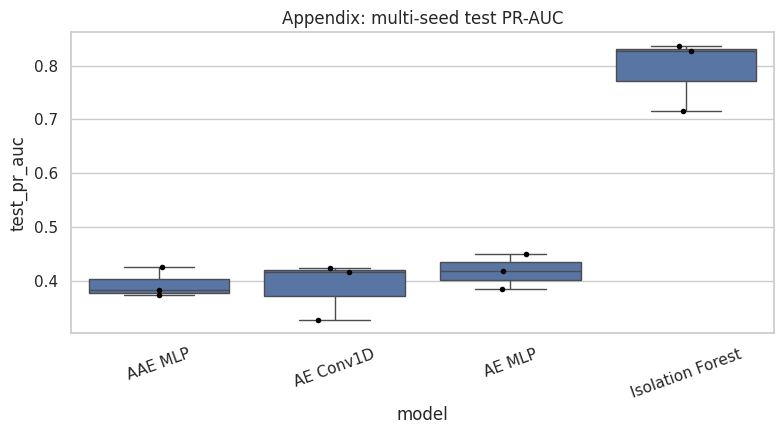

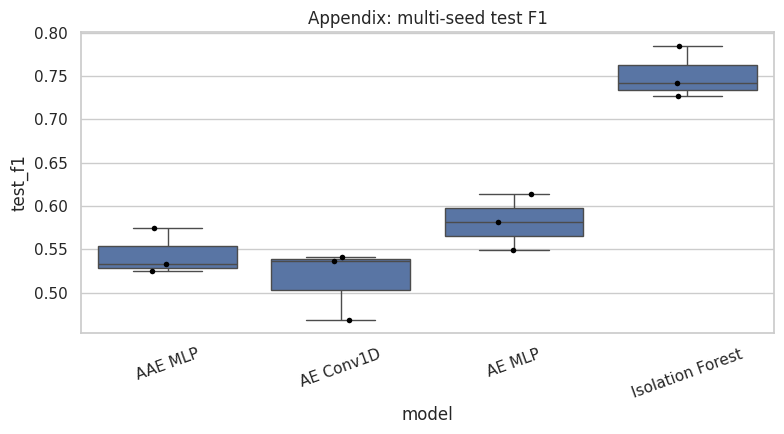

In [6]:
plot_df = stability.copy()
plt.figure(figsize=(8, 4.5))
ax = sns.boxplot(data=plot_df, x='model', y='test_pr_auc')
sns.stripplot(data=plot_df, x='model', y='test_pr_auc', color='black', size=4, ax=ax)
ax.set_title('Appendix: multi-seed test PR-AUC')
ax.tick_params(axis='x', rotation=20)
rpt.savefig(FIGURES_DIR / 'appendix_multiseed_test_pr_auc.png')
plt.show()

plt.figure(figsize=(8, 4.5))
ax = sns.boxplot(data=plot_df, x='model', y='test_f1')
sns.stripplot(data=plot_df, x='model', y='test_f1', color='black', size=4, ax=ax)
ax.set_title('Appendix: multi-seed test F1')
ax.tick_params(axis='x', rotation=20)
rpt.savefig(FIGURES_DIR / 'appendix_multiseed_test_f1.png')
plt.show()

## Official artifact index

In [7]:
artifacts = sorted([p for p in OFFICIAL_ROOT.rglob('*') if p.is_file()])
manifest = pd.DataFrame({'artifact': [str(p.relative_to(OFFICIAL_ROOT)) for p in artifacts]})
manifest.to_csv(TABLES_DIR / 'appendix_official_artifact_index.csv', index=False)
display(manifest)

,artifact
0,appendix/figures/appendix_multiseed_test_f1.png
1,appendix/figures/appendix_multiseed_test_pr_au...
2,appendix/runs/multiseed_stability/aae_mlp_seed...
3,appendix/runs/multiseed_stability/aae_mlp_seed...
4,appendix/runs/multiseed_stability/aae_mlp_seed...
...,...
569,tables/preprocessing_loss_ablation.csv
570,tables/preprocessing_summary.csv
571,tables/segment_lengths.csv
572,tables/window_count_sensitivity.csv
